Introducción a la Ciencia de Datos 2026 | Maestría en Ciencias de la Computación | CICESE

Práctica 2: Procesamiento de Datasets

# Práctica 2: Procesamiento de Datasets

**Autor:** [Benjamín Hernández Herrera](https://github.com/ben2her)


## Conjunto de Datos

El dataset encontrado consiste en casi 30000 canciones de Spotify capturadas con la API brindada por spotify. Estos datos fueron capturados y subidos a kaggle por [Joakim Arvidsson](https://www.kaggle.com/joebeachcapital)·

**Fuente:** [30000 Spotify Songs - Kaggle](https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs/data)

### Importación de librerías

In [2]:
import kagglehub
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import math
from importlib.metadata import version

modules = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'scikit-learn', 'kagglehub', 'plotly']

for module in modules:
    print(f"{module}: {version(module)}")


numpy: 2.1.3
pandas: 2.2.3
matplotlib: 3.10.0
seaborn: 0.13.2
scikit-learn: 1.6.1
kagglehub: 1.0.2
plotly: 5.24.1


### Descripción de variables

| Variable | Tipo | Descripción |
|---|---|---|
| `track_id` |  | ID único de la canción. |
| `track_name` | Carácter | Nombre de la canción. |
| `track_artist` | Carácter | Artista de la canción. |
| `track_popularity` | Decimal | Popularidad de la canción (0–100); valores más altos indican mayor popularidad. |
| `track_album_id` | Carácter | ID único del álbum. |
| `track_album_name` | Carácter | Nombre del álbum de la canción. |
| `track_album_release_date` | Carácter | Fecha de lanzamiento del álbum. |
| `playlist_name` | Carácter | Nombre de la playlist. |
| `playlist_id` | Carácter | ID de la playlist. |
| `playlist_genre` | Carácter | Género musical de la playlist. |
| `playlist_subgenre` | Carácter | Subgénero musical de la playlist. |
| `danceability` | Decimal | Qué tan adecuada es la canción para bailar. Va de 0.0 (menos bailable) a 1.0 (más bailable). |
| `energy` | Decimal | Medida de la intensidad y actividad de la canción. Va de 0.0 a 1.0. |
| `key` | Decimal | Tonalidad estimada de la canción. `0 = C`, `1 = C♯/D♭`, `2 = D`, etc. `-1` indica que no se detectó tonalidad. |
| `loudness` | Decimal | Volumen general de la canción, medido en decibeles (dB). Generalmente va de -60 a 0 dB. |
| `mode` | Decimal | Modalidad de la canción: `1` = mayor y `0` = menor. |
| `speechiness` | Decimal | Presencia de palabras habladas en la canción. |
| `acousticness` | Decimal | Probabilidad de que la canción sea acústica. Va de 0.0 a 1.0. |
| `instrumentalness` | Decimal | Probabilidad de que la canción no contenga voces. Valores cercanos a 1 indican mayor probabilidad de que sea instrumental. |
| `liveness` | Decimal | Probabilidad de que la grabación haya sido realizada en vivo. |
| `valence` | Decimal | Positividad musical percibida. Valores altos representan canciones más alegres o positivas. |
| `tempo` | Decimal | Tempo estimado de la canción, expresado en pulsaciones por minuto (BPM). |
| `duration_ms` | Decimal | Duración de la canción en milisegundos. |

In [3]:
path = kagglehub.dataset_download("joebeachcapital/30000-spotify-songs")
print("Path to dataset files:", path)

Using Colab cache for faster access to the '30000-spotify-songs' dataset.
Path to dataset files: /kaggle/input/30000-spotify-songs


### Análisis exploratorio de Datos

In [4]:
dataset_path = '/kaggle/input/30000-spotify-songs/spotify_songs.csv'
df = pd.read_csv(dataset_path)
print("Registros: ", df.shape[0])
print("Atributos: ", df.shape[1])
print("===== PRIMEROS 5 REGISTROS =====")
df.head(5).T

Registros:  32833
Atributos:  23
===== PRIMEROS 5 REGISTROS =====


,0,1,2,3,4
track_id,6f807x0ima9a1j3VPbc7VN,0r7CVbZTWZgbTCYdfa2P31,1z1Hg7Vb0AhHDiEmnDE79l,75FpbthrwQmzHlBJLuGdC7,1e8PAfcKUYoKkxPhrHqw4x
track_name,I Don't Care (with Justin Bieber) - Loud Luxur...,Memories - Dillon Francis Remix,All the Time - Don Diablo Remix,Call You Mine - Keanu Silva Remix,Someone You Loved - Future Humans Remix
track_artist,Ed Sheeran,Maroon 5,Zara Larsson,The Chainsmokers,Lewis Capaldi
track_popularity,66,67,70,60,69
track_album_id,2oCs0DGTsRO98Gh5ZSl2Cx,63rPSO264uRjW1X5E6cWv6,1HoSmj2eLcsrR0vE9gThr4,1nqYsOef1yKKuGOVchbsk6,7m7vv9wlQ4i0LFuJiE2zsQ
track_album_name,I Don't Care (with Justin Bieber) [Loud Luxury...,Memories (Dillon Francis Remix),All the Time (Don Diablo Remix),Call You Mine - The Remixes,Someone You Loved (Future Humans Remix)
track_album_release_date,2019-06-14,2019-12-13,2019-07-05,2019-07-19,2019-03-05
playlist_name,Pop Remix,Pop Remix,Pop Remix,Pop Remix,Pop Remix
playlist_id,37i9dQZF1DXcZDD7cfEKhW,37i9dQZF1DXcZDD7cfEKhW,37i9dQZF1DXcZDD7cfEKhW,37i9dQZF1DXcZDD7cfEKhW,37i9dQZF1DXcZDD7cfEKhW
playlist_genre,pop,pop,pop,pop,pop


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

Conteo de valores nulos y únicos

In [6]:
pd.DataFrame({
    'count:': df.shape[0],
    'nulls:': df.isnull().sum(),
    'nulls(%):': df.isnull().mean() * 100,
    'cardinality:' : df.nunique()
})

,count:,nulls:,nulls(%):,cardinality:
track_id,32833,0,0.000000,28356
track_name,32833,5,0.015229,23449
track_artist,32833,5,0.015229,10692
track_popularity,32833,0,0.000000,101
track_album_id,32833,0,0.000000,22545
track_album_name,32833,5,0.015229,19743
track_album_release_date,32833,0,0.000000,4530
playlist_name,32833,0,0.000000,449
playlist_id,32833,0,0.000000,471
playlist_genre,32833,0,0.000000,6


In [7]:
print(f"Registros duplicados: {df.duplicated().sum()}")

Registros duplicados: 0


In [8]:
a = df.isna().sum()
a[a > 0]

,0
track_name,5
track_artist,5
track_album_name,5


Se encontró que una canción se encuentra repetida en varias playlist, por lo que se eliminarán los duplicados. Algo a considerar a futuro es que al eliminar los datos duplicados se pierden algunos generos relacionados con otras playlist de la canción.

In [9]:
print(f"Registros duplicados: {df.duplicated().sum()}")
df[df['track_id'].duplicated(keep=False)].sort_values('track_id', ascending=False)

Registros duplicados: 0


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
30939,7zsXy7vlHdItvUSH8EwQss,Cold Water,Major Lazer,69,3Kmo85mapQ2wTaCAHBkKsK,Cold Water,2016-07-22,EDM/POP,6gHk5RFrnALbDNJdaXKivi,edm,...,6,-5.092,0,0.0432,0.0736,0.000000,0.1560,0.501,92.943,185360
2850,7zsXy7vlHdItvUSH8EwQss,Cold Water,Major Lazer,69,3Kmo85mapQ2wTaCAHBkKsK,Cold Water,2016-07-22,ElectroPop 2020,4frhr6RQM2fMOm2mpvOVo6,pop,...,6,-5.092,0,0.0432,0.0736,0.000000,0.1560,0.501,92.943,185360
20517,7zsXy7vlHdItvUSH8EwQss,Cold Water,Major Lazer,69,3Kmo85mapQ2wTaCAHBkKsK,Cold Water,2016-07-22,Latin/Hip Hop/Dancehall/Soca,2rg9LCyvaMQvnCE2hVndpR,latin,...,6,-5.092,0,0.0432,0.0736,0.000000,0.1560,0.501,92.943,185360
28932,7zHrHnVSQwI95FGHewXDl8,Do Bad Well (feat. Nevve),KSHMR,62,3BAigRfKg2iyWJuWlZCZZQ,Do Bad Well (feat. Nevve),2019-10-11,Bounce United,08QTrfsYYouffgnPjmllAQ,edm,...,5,-4.755,1,0.1130,0.0512,0.000315,0.2340,0.415,127.964,204375
32074,7zHrHnVSQwI95FGHewXDl8,Do Bad Well (feat. Nevve),KSHMR,62,3BAigRfKg2iyWJuWlZCZZQ,Do Bad Well (feat. Nevve),2019-10-11,Epic Bass Drops | Best House Mixes,4IS7o1utOzhimFEFnj9gmu,edm,...,5,-4.755,1,0.1130,0.0512,0.000315,0.2340,0.415,127.964,204375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9387,00QyLmjxaSEE8qIZQjBXBj,We Own It (Fast & Furious),2 Chainz,59,1jg2UPoSAr7CDPsEXcabo1,Fast & Furious 6,2013-01-01,RAP Gangsta,1Z1gW89x4MSBjkvVjGg7DQ,rap,...,8,-4.573,1,0.4080,0.0521,0.000000,0.0568,0.552,171.966,227893
28968,00QyLmjxaSEE8qIZQjBXBj,We Own It (Fast & Furious),2 Chainz,59,1jg2UPoSAr7CDPsEXcabo1,Fast & Furious 6,2013-01-01,Locker Room,37i9dQZF1DX8SaiEt4OVJw,edm,...,8,-4.573,1,0.4080,0.0521,0.000000,0.0568,0.552,171.966,227893
23850,00QyLmjxaSEE8qIZQjBXBj,We Own It (Fast & Furious),2 Chainz,59,1jg2UPoSAr7CDPsEXcabo1,Fast & Furious 6,2013-01-01,Today's Hits (Clean),7ENISpOJhocpMJVcGb0qcT,r&b,...,8,-4.573,1,0.4080,0.0521,0.000000,0.0568,0.552,171.966,227893
32084,00Gu3RMpDW2vO9PjlMVFDL,Hide Away (feat. Envy Monroe),Blasterjaxx,42,5pqG85igfoeWcCDIsSi9x7,Hide Away (feat. Envy Monroe),2019-06-21,Epic Bass Drops | Best House Mixes,4IS7o1utOzhimFEFnj9gmu,edm,...,10,-4.894,1,0.0421,0.0249,0.000000,0.3610,0.134,130.001,188000


In [11]:
df_respaldo = df.copy()

In [15]:
df[df['track_name'].isna()]

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
8151,69gRFGOWY9OMpFJgFol1u0,NaN,NaN,0,717UG2du6utFe7CdmpuUe3,NaN,2012-01-05,HIP&HOP,5DyJsJZOpMJh34WvUrQzMV,rap,...,6,-7.635,1,0.1760,0.0410,0.00000,0.1160,0.649,95.999,282707
9282,5cjecvX0CmC9gK0Laf5EMQ,NaN,NaN,0,3luHJEPw434tvNbme3SP8M,NaN,2017-12-01,GANGSTA Rap,5GA8GDo7RQC3JEanT81B3g,rap,...,11,-5.364,0,0.3190,0.0534,0.00000,0.5530,0.191,146.153,202235
9283,5TTzhRSWQS4Yu8xTgAuq6D,NaN,NaN,0,3luHJEPw434tvNbme3SP8M,NaN,2017-12-01,GANGSTA Rap,5GA8GDo7RQC3JEanT81B3g,rap,...,10,-5.907,0,0.3070,0.0963,0.00000,0.0888,0.505,86.839,206465
19568,3VKFip3OdAvv4OfNTgFWeQ,NaN,NaN,0,717UG2du6utFe7CdmpuUe3,NaN,2012-01-05,Reggaeton viejito🔥,0si5tw70PIgPkY1Eva6V8f,latin,...,11,-6.075,0,0.0366,0.0606,0.00653,0.1030,0.726,97.017,252773
19811,69gRFGOWY9OMpFJgFol1u0,NaN,NaN,0,717UG2du6utFe7CdmpuUe3,NaN,2012-01-05,latin hip hop,3nH8aytdqNeRbcRCg3dw9q,latin,...,6,-7.635,1,0.1760,0.0410,0.00000,0.1160,0.649,95.999,282707


In [21]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
track_id,32833,28356,7BKLCZ1jbUBVqRi2FVlTVw,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_name,32828,23449,Poison,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_artist,32828,10692,Martin Garrix,161,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_popularity,32833.0,NaN,NaN,NaN,42.477081,24.984074,0.0,24.0,45.0,62.0,100.0
track_album_id,32833,22545,5L1xcowSxwzFUSJzvyMp48,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_album_name,32828,19743,Greatest Hits,139,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_album_release_date,32833,4530,2020-01-10,270,NaN,NaN,NaN,NaN,NaN,NaN,NaN
playlist_name,32833,449,Indie Poptimism,308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
playlist_id,32833,471,4JkkvMpVl4lSioqQjeAL0q,247,NaN,NaN,NaN,NaN,NaN,NaN,NaN
playlist_genre,32833,6,edm,6043,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Separación de variables categóricas, numéricas (enteras y reales)

In [22]:
numeric_cols = df.select_dtypes(include="number").columns
integer_cols = df.select_dtypes(include="integer").columns
float_cols = df.select_dtypes(include="floating").columns
categorical_cols = df.select_dtypes(include="object").columns

print("Enteras:", integer_cols.tolist())
print("Reales:", float_cols.tolist())
print("Categóricas:", categorical_cols.tolist())

Enteras: ['track_popularity', 'key', 'mode', 'duration_ms']
Reales: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
Categóricas: ['track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre']


Variables con números enteros

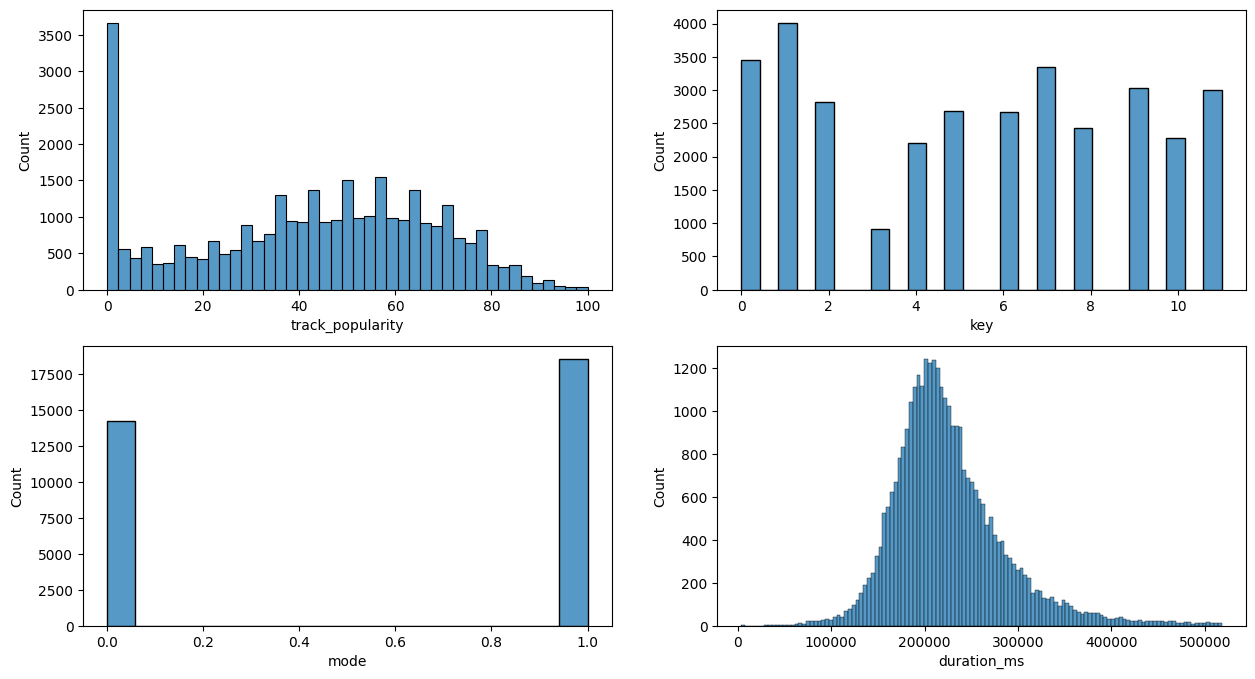

In [38]:
ncols = 2
nrows = math.ceil(len(integer_cols)/ncols)
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(15, 4*nrows)
)
axes = axes.flatten()

for ax, col in zip(axes, integer_cols):
  sns.histplot(
      data=df,
      x=col,
      ax=ax,
      # kde=True,
      # multiple='stack'
  )

plt.show()

**Análisis de Variables Enteras:**
* **`track_popularity`:** Presenta un comportamiento bimodal muy marcado. Se observa una gran acumulación de canciones con popularidad cercana a 0 (posiblemente pistas muy nuevas, descatalogadas o sin reproducciones) y una distribución aproximadamente normal centrada alrededor de los 45-50 puntos para el resto de la música.
* **`key`:** Las tonalidades musicales estimadas están bien distribuidas, destacando picos ligeros en las tonalidades `0 (Do / C)`, `1 (Do♯ / C♯)` y `7 (Sol / G)`, que son comunes en la composición de música pop y electrónica por su facilidad de ejecución y sonido brillante.
* **`mode`:** Existe un predominio del modo mayor (`1`) sobre el modo menor (`0`). Esto indica que el catálogo analizado tiende a composiciones percibidas tradicionalmente como más alegres o estables.
* **`duration_ms`:** Muestra una clara distribución unimodal simétrica (campana de Gauss) muy estrecha, concentrándose la inmensa mayoría de las canciones en un rango de 3 a 4 minutos (entre 180,000 y 240,000 milisegundos), ideal para el formato estándar de difusión radial y streaming.

Variables con números reales

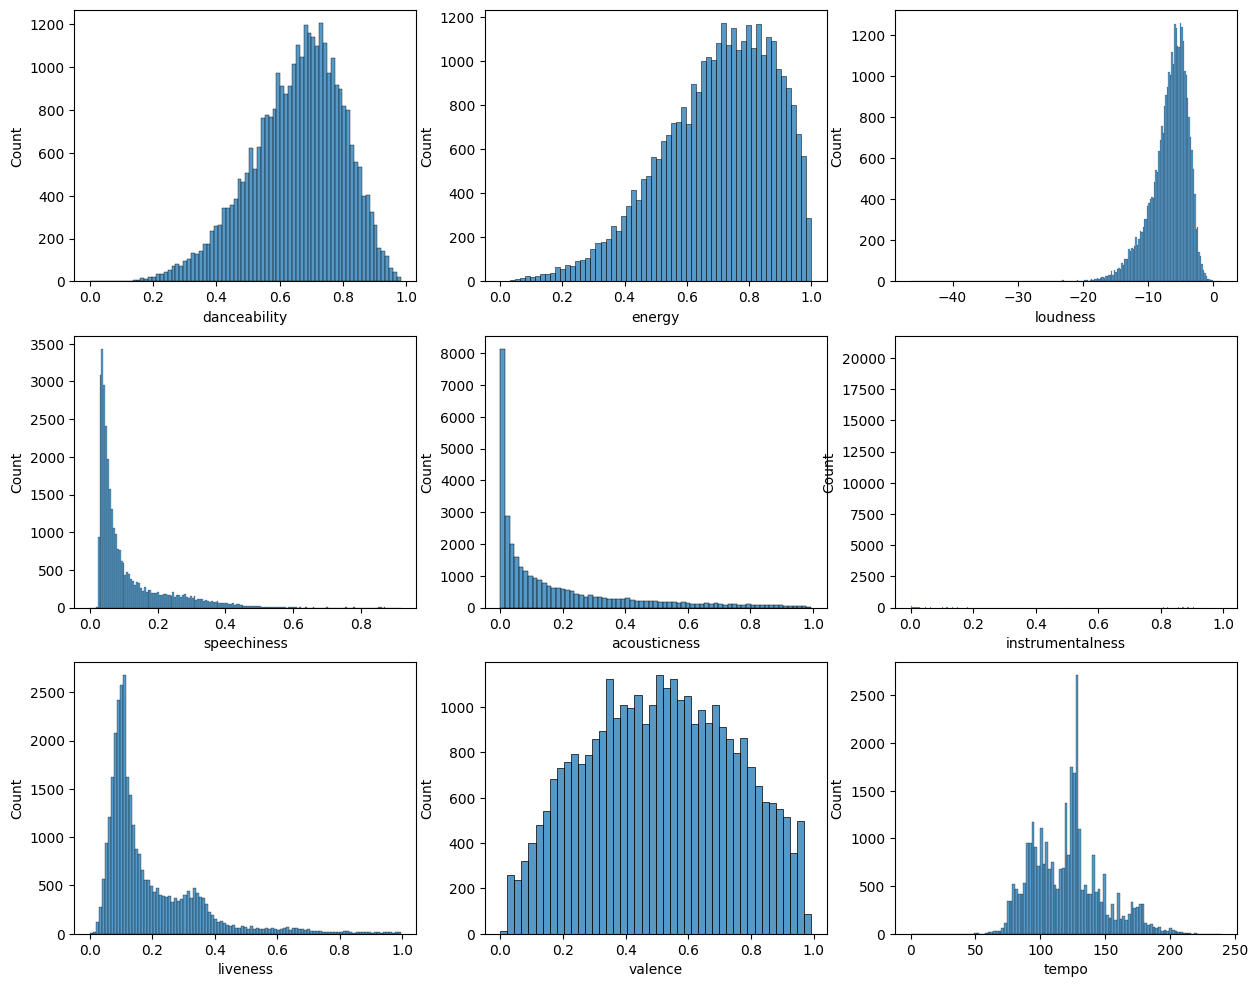

In [24]:
ncols = 3
nrows = math.ceil(len(float_cols)/ncols)
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(15, 4*nrows)
)
axes = axes.flatten()

for ax, col in zip(axes, float_cols):
  sns.histplot(
      data=df,
      x=col,
      ax=ax,
      # kde=True,
      # multiple='stack'
  )

plt.show()

Se observa que no se grafica el atributo de `instrumentalness`

Ahora se graficara con otro método

<Axes: >

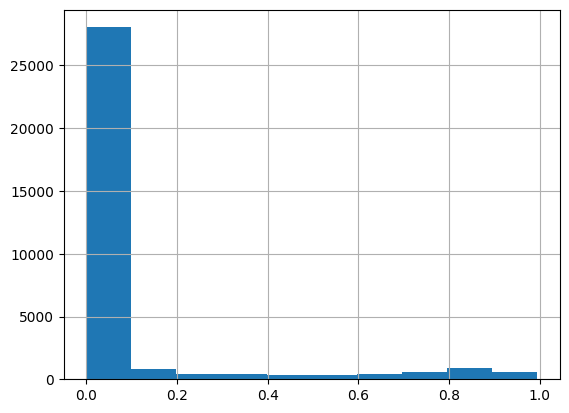

In [25]:
df['instrumentalness'].hist()

**Análisis de Variables Reales (Atributos de Audio):**
* **`danceability` y `energy`:** Ambas variables presentan una asimetría hacia la izquierda (valores altos). La mayoría de las canciones tienen niveles altos de energía y son altamente bailables, lo que coincide con el perfil de un catálogo comercial dinámico.
* **`loudness`:** El volumen en decibelios (dB) se concentra sesgado hacia valores altos (entre -10 y -4 dB), evidenciando la tendencia moderna del mercado conocida como "Guerra del Volumen" (*Loudness War*) para hacer las canciones artificialmente más competitivas en volumen.
* **`speechiness` y `acousticness`:** Muestran una distribución exponencial decreciente con picos masivos muy cercanos a 0. Esto revela que la gran mayoría del dataset consiste en música predominantemente cantada (no hablada, tipo rap puro o podcasts) y de naturaleza altamente eléctrica/sintética en lugar de acústica.
* **`instrumentalness`:** Prácticamente la totalidad de los datos se agrupa en 0, lo que confirma que el catálogo está dominado por canciones que contienen voz. Muy pocas pistas son puramente instrumentales.
* **`liveness`:** El fuerte sesgo hacia valores bajos (< 0.2) indica que las grabaciones son, en su gran mayoría, de estudio y no registros de conciertos o eventos en vivo.
* **`valence`:** Presenta una distribución notablemente uniforme y balanceada en todo su rango (0 a 1). Esto denota que hay un equilibrio saludable entre canciones con un matiz emocional positivo/alegre y negativo/melancólico.
* **`tempo`:** Exhibe una distribución unimodal con una media clara en torno a los 120-125 BPM (Beats Por Minuto), que es el estándar rítmico para géneros bailables modernos como el House, Pop y EDM.

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

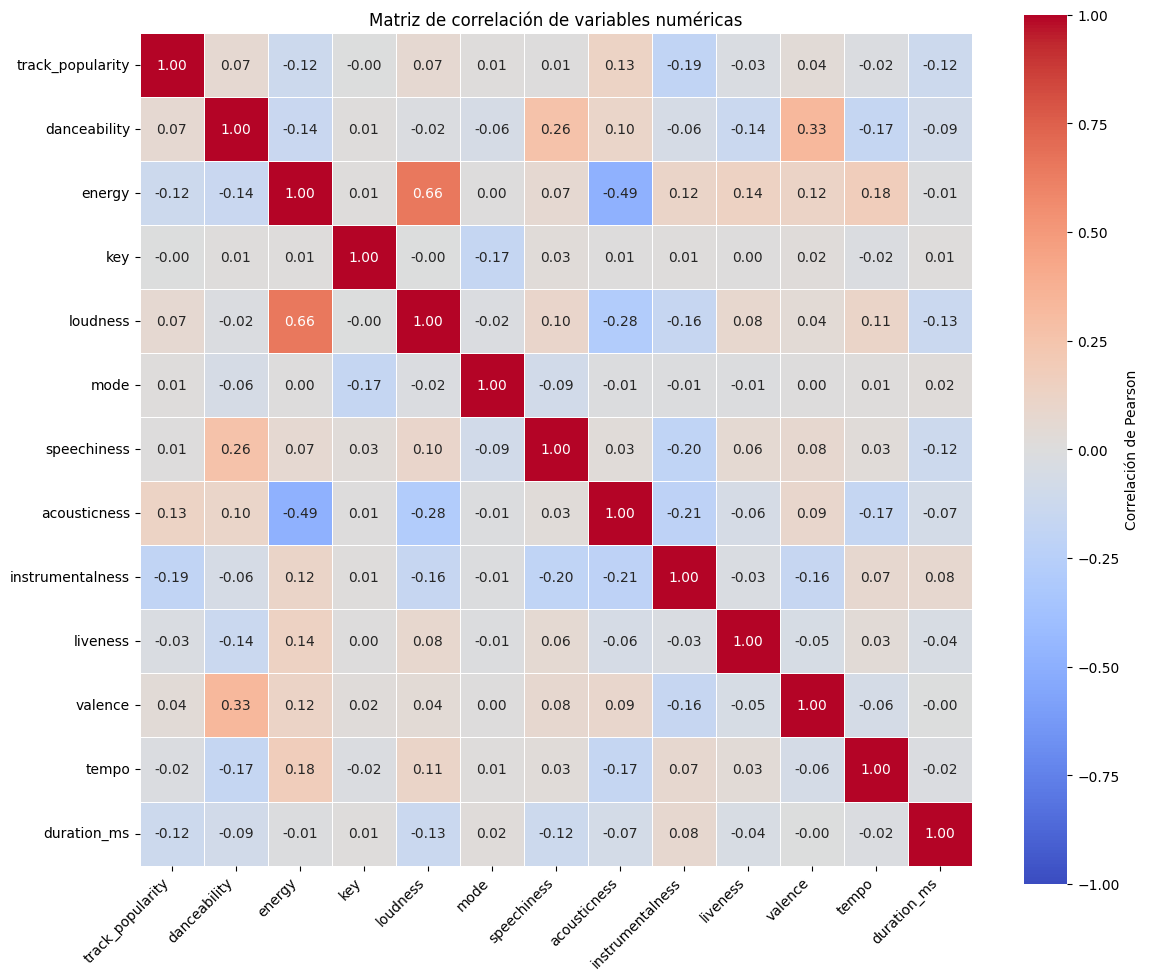

In [27]:
# Matriz de correlación de Pearson
corr = df[numeric_cols].corr(method='spearman')

# Graficar
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    annot=True,          # Mostrar coeficientes
    fmt='.2f',           # Dos decimales
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Correlación de Pearson'}
)

plt.title('Matriz de correlación de variables numéricas')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Utilizando el método de Spearman podemos destacar las siguientes relaciones de los atributos de audio:
1. **Fuerte Correlación Positiva (`energy` vs. `loudness` = 0.66):** Es la relación más fuerte del dataset. Confirma el principio físico de que a mayor energía y densidad instrumental en la producción de la pista, mayor es el volumen general de reproducción (dB).
2. **Correlación Moderada Positiva (`danceability` vs. `valence` = 0.33):** Sugiere de manera lógica que los ritmos diseñados expresamente para bailar suelen estar acompañados de tonalidades alegres, optimistas y de alta positividad musical.
3. **Fuerte Correlación Negativa (`energy` vs. `acousticness` = -0.49):** A medida que una canción tiene más energía, disminuye drásticamente su probabilidad de ser acústica. La energía en la música moderna está íntimamente ligada al uso de instrumentos eléctricos y sintetizadores modernos.
4. **Baja Correlación con la Popularidad:** Sorprendentemente, ninguna de las características físicas de audio individuales (`danceability`, `tempo`, `energy`, etc.) muestra una correlación lineal o monótona fuerte directa con la popularidad de la pista (`track_popularity`), siendo el volumen (`loudness` = 0.07) y el año de lanzamiento los que apenas muestran una influencia ligera. Esto indica que el éxito de una canción depende de interacciones complejas de variables o de factores externos al audio (como marketing, artistas y tendencias).

---
### Limpieza de datos




Se eliminan los datos duplicados encontrados

In [28]:
df_copy = df.drop_duplicates(subset='track_id')

In [29]:
nul = df_copy.isna().sum()
nul[nul > 0]

,0
track_name,4
track_artist,4
track_album_name,4


Se eliminan los datos vacíos

In [30]:
df_copy = df_copy.dropna()

Se eliminaron los registros duplicados basados en `track_id` para evitar redundancias que sesguen los análisis estadísticos. Adicionalmente, se removieron de forma segura las 4 filas que presentaban valores nulos en columnas críticas como el nombre de la canción y el artista, obteniendo un conjunto de datos limpio de 28,352 registros únicos.

---
### Aumento de datos

Aplicamos una técnica de inyección de ruido gaussiano moderado a las características numéricas continuas de audio para simular variabilidad técnica de grabación.

In [34]:
# Aumento de datos utilizando inyección de ruido gaussiano en variables continuas
np.random.seed(42)

# Seleccionamos columnas numéricas continuas clave para el aumento
audio_features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

# Creamos una copia para los datos aumentados
df_augmented = df_copy.copy()

# Definimos una desviación estándar pequeña para el ruido (ej. 1% del rango aproximado de cada variable)
for col in audio_features:
    std_dev = df_copy[col].std() * 0.02  # 2% de la desviación original
    noise = np.random.normal(0, std_dev, size=len(df_copy))
    df_augmented[col] = df_augmented[col] + noise

# Unimos el dataset original con el aumentado para expandir el conjunto de datos
df_combined_augmented = pd.concat([df_copy, df_augmented], ignore_index=True)
print(f"Dimensiones originales: {df_copy.shape}")
print(f"Dimensiones tras aumento de datos: {df_combined_augmented.shape}")

Dimensiones originales: (28352, 23)
Dimensiones tras aumento de datos: (56704, 23)


La inyección de ruido gaussiano moderado (2% de la desviación estándar original) sobre las características continuas de audio permitió duplicar de manera artificial el tamaño del dataset, alcanzando 56,704 registros. Esta técnica introduce una variabilidad técnica simulada sumamente útil para robustecer futuros modelos de aprendizaje automático ante imperfecciones de grabación.

---
### Extracción de características

Convertimos la duración de milisegundos a minutos y extraemos información temporal (año y mes) a partir de la fecha de lanzamiento del álbum.

In [35]:
# Extracción de características útiles (Feature Extraction)
df_extracted = df_copy.copy()

# 1. Convertir duración a minutos para mejor interpretabilidad
df_extracted['duration_min'] = df_extracted['duration_ms'] / 60000.0

# 2. Extraer Año y Mes de lanzamiento a partir de la fecha (manejando formatos inconsistentes)
df_extracted['track_album_release_date'] = pd.to_datetime(df_extracted['track_album_release_date'], errors='coerce', format='mixed')
df_extracted['release_year'] = df_extracted['track_album_release_date'].dt.year
df_extracted['release_month'] = df_extracted['track_album_release_date'].dt.month.fillna(-1).astype(int)

# 3. Clasificación de tempo (BPM) en rangos musicales comunes
def classify_tempo(bpm):
    if bpm < 100: return 'Slow'
    elif bpm <= 130: return 'Medium'
    else: return 'Fast'

df_extracted['tempo_class'] = df_extracted['tempo'].apply(classify_tempo)

display(df_extracted[['track_name', 'duration_min', 'release_year', 'tempo_class']].head())
print(f"Nuevas columnas añadidas: {df_extracted.shape[1] - df_copy.shape[1]}")

,track_name,duration_min,release_year,tempo_class
0,I Don't Care (with Justin Bieber) - Loud Luxur...,3.245900,2019,Medium
1,Memories - Dillon Francis Remix,2.710000,2019,Slow
2,All the Time - Don Diablo Remix,2.943600,2019,Medium
3,Call You Mine - Keanu Silva Remix,2.818217,2019,Medium
4,Someone You Loved - Future Humans Remix,3.150867,2019,Medium


Nuevas columnas añadidas: 4


In [40]:
df_extracted.head(5).T

,0,1,2,3,4
track_id,6f807x0ima9a1j3VPbc7VN,0r7CVbZTWZgbTCYdfa2P31,1z1Hg7Vb0AhHDiEmnDE79l,75FpbthrwQmzHlBJLuGdC7,1e8PAfcKUYoKkxPhrHqw4x
track_name,I Don't Care (with Justin Bieber) - Loud Luxur...,Memories - Dillon Francis Remix,All the Time - Don Diablo Remix,Call You Mine - Keanu Silva Remix,Someone You Loved - Future Humans Remix
track_artist,Ed Sheeran,Maroon 5,Zara Larsson,The Chainsmokers,Lewis Capaldi
track_popularity,66,67,70,60,69
track_album_id,2oCs0DGTsRO98Gh5ZSl2Cx,63rPSO264uRjW1X5E6cWv6,1HoSmj2eLcsrR0vE9gThr4,1nqYsOef1yKKuGOVchbsk6,7m7vv9wlQ4i0LFuJiE2zsQ
track_album_name,I Don't Care (with Justin Bieber) [Loud Luxury...,Memories (Dillon Francis Remix),All the Time (Don Diablo Remix),Call You Mine - The Remixes,Someone You Loved (Future Humans Remix)
track_album_release_date,2019-06-14 00:00:00,2019-12-13 00:00:00,2019-07-05 00:00:00,2019-07-19 00:00:00,2019-03-05 00:00:00
playlist_name,Pop Remix,Pop Remix,Pop Remix,Pop Remix,Pop Remix
playlist_id,37i9dQZF1DXcZDD7cfEKhW,37i9dQZF1DXcZDD7cfEKhW,37i9dQZF1DXcZDD7cfEKhW,37i9dQZF1DXcZDD7cfEKhW,37i9dQZF1DXcZDD7cfEKhW
playlist_genre,pop,pop,pop,pop,pop


Se crearon nuevas variables interpretables: la duración en minutos (`duration_min`), la información temporal (`release_year` y `release_month`) para capturar tendencias históricas, y una discretización del tempo (`tempo_class`) en categorías musicales.

---
### Reducción de dimensionalidad
Aplicamos Análisis de Componentes Principales (PCA) estandarizando previamente las variables físicas continuas de las canciones.

Varianza explicada por componente: [0.24094215 0.16770916]
Varianza explicada total acumulada (2 CP): 0.4087


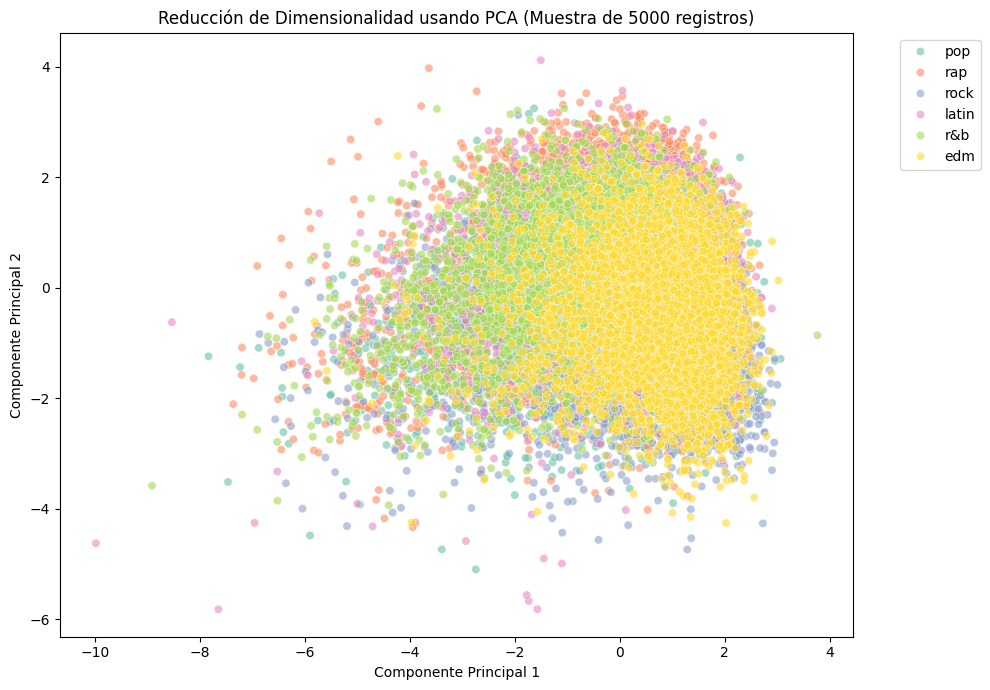

In [44]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Seleccionamos las características numéricas para la reducción de dimensionalidad
features_for_pca = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
X_pca = df_copy[features_for_pca]

# Es sumamente importante estandarizar los datos antes de aplicar PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# Inicializamos PCA para reducir a 2 componentes principales visualizables
pca = PCA(n_components=2)
X_pca_transformed = pca.fit_transform(X_scaled)

# Añadimos los componentes al dataframe
df_pca_result = df_copy.copy()
df_pca_result['PCA1'] = X_pca_transformed[:, 0]
df_pca_result['PCA2'] = X_pca_transformed[:, 1]

# Mostramos la varianza explicada por cada componente
print(f"Varianza explicada por componente: {pca.explained_variance_ratio_}")
print(f"Varianza explicada total acumulada (2 CP): {sum(pca.explained_variance_ratio_):.4f}")

# Graficamos la reducción de dimensionalidad coloreando por el género de la playlist
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca_result, x='PCA1', y='PCA2', hue='playlist_genre', alpha=0.6, palette='Set2')
plt.title('Reducción de Dimensionalidad usando PCA (Muestra de 5000 registros)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Aunque las dos primeras componentes principales del PCA sintetizan un 40.87% de la varianza total de los atributos de audio, la proyección bidimensional revela una alta superposición entre los diferentes géneros musicales. Esto sugiere que las características físicas continuas por sí solas no definen fronteras lineales rígidas entre géneros, requiriéndose estructuras más complejas para su clasificación.

---
### Selección de características
Se utiliza un modelo de Bosque Aleatorio (Random Forest) para evaluar la importancia de cada variable respecto a la popularidad de la canción (`track_popularity`).


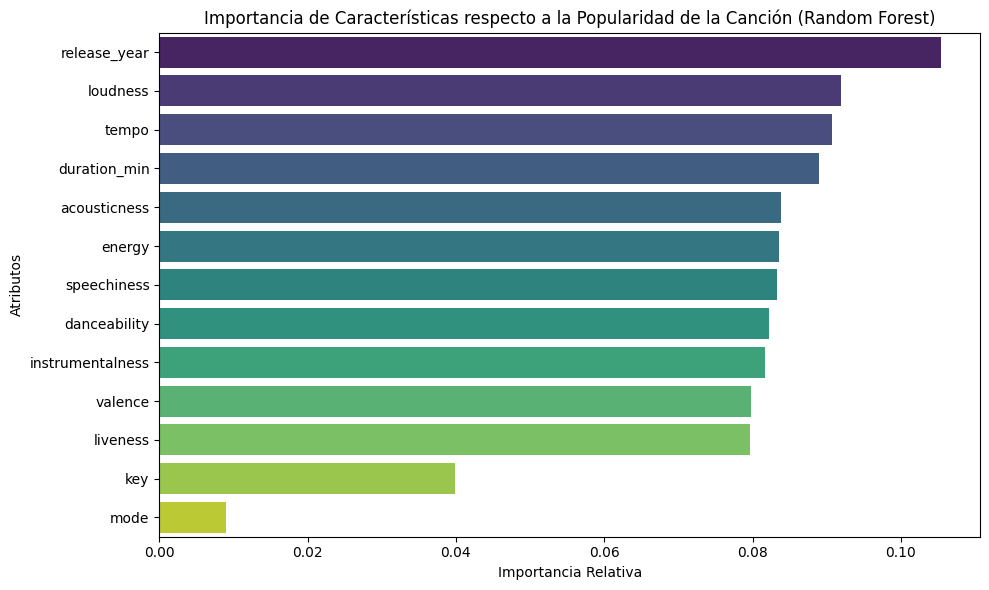

In [45]:
from sklearn.ensemble import RandomForestRegressor

# Selección de características basada en importancia por Random Forest
# Objetivo: Determinar qué características físicas influyen más en 'track_popularity'

# Limpiamos filas con valores nulos generados en la extracción de fechas si fuera el caso
df_selection = df_extracted.dropna(subset=['release_year']).copy()

features_for_selection = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
                          'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min', 'release_year']

X_sel = df_selection[features_for_selection]
y_sel = df_selection['track_popularity']

# Entrenamos un estimador rápido
rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_sel, y_sel)

# Extraemos y ordenamos las importancias
importances = pd.Series(rf.feature_importances_, index=features_for_selection).sort_values(ascending=False)

# Graficamos
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis', hue=importances.index, legend=False)
plt.title('Importancia de Características respecto a la Popularidad de la Canción (Random Forest)')
plt.xlabel('Importancia Relativa')
plt.ylabel('Atributos')
plt.tight_layout()
plt.show()

**Conclusión de Selección de características:**
El modelo de Random Forest determinó que el año de lanzamiento (`release_year`), el volumen (`loudness`), el tempo (`tempo`) y la duración de la canción (`duration_min`) son los factores individuales con mayor importancia relativa asociados a la popularidad de una pista. Atributos como la tonalidad (`key`) y la modalidad (`mode`) mostraron una influencia sumamente baja sobre esta métrica.

Uso de IA. Para este notebook se utilizó Gemini para la corrección de la gramática y ortografía, a su vez para la generación de tablas con la sintáxis de markdown.